# 09 — IoT Sim Success Sınıflandırması

**Soru:** Hasat başarısız olacak mı alarm sistemi, sadece IoT sensör + Sentinel-2 verisiyle çalışabilir mi?

**Karşılaştırma:**
- **Full model** (notebook 06): WOFOST feature'ları dahil — AUC=0.981
- **IoT model**: Sadece sensörden/uydadan gelebilecek feature'lar

**Çıkarılan WOFOST feature'ları:** `mean_rftra`, `max_tagp`, `max_dvs`  
**Eklenen IoT feature'ları:** `mean_soil_temp`, `mean_soil_moisture`

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import joblib
import duckdb
import shap
from pathlib import Path
from sklearn.metrics import roc_auc_score, RocCurveDisplay, classification_report

from src.data.loader import RAW_PATH

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROCESSED = Path('../data/processed')
OUTPUTS   = Path('../outputs')
FIGS      = OUTPUTS / 'figures' / 'sim_success'
MODELS    = OUTPUTS / 'models' / 'sim_success'

CUTOFFS    = [30, 60, 90]
TEST_YEARS = [2023, 2024]
TARGET     = 'sim_success'

with open(PROCESSED / 'crop_te_map.json') as f:
    d = json.load(f)
global_mean = d.pop('__global_mean__')
crop_te_map = d

print('Hazır.')

Hazır.


## 1. Veri yükleme

In [2]:
def load_cutoff_iot(n_days: int) -> pd.DataFrame:
    return duckdb.query(f"""
        WITH season_start AS (
            SELECT
                latitude, longitude, elevation,
                crop_name, variety_name, year, wav_scenario, WAV,
                MIN(DATETIME::TIMESTAMP) AS start_ts,
                MAX(harvest_twso)        AS harvest_twso,
                MAX(sim_success)         AS sim_success
            FROM '{RAW_PATH}'
            GROUP BY latitude, longitude, elevation,
                     crop_name, variety_name, year, wav_scenario, WAV
        ),
        filtered AS (
            SELECT r.*
            FROM '{RAW_PATH}' r
            JOIN season_start s
              ON  r.latitude     = s.latitude
              AND r.longitude    = s.longitude
              AND r.crop_name    = s.crop_name
              AND r.year         = s.year
              AND r.wav_scenario = s.wav_scenario
            WHERE r.DATETIME::TIMESTAMP < s.start_ts + INTERVAL '{n_days} days'
        )
        SELECT
            f.latitude, f.longitude, f.elevation,
            f.crop_name, f.year, f.wav_scenario, f.WAV,
            MAX(f.harvest_twso)        AS harvest_twso,
            MAX(f.sim_success)         AS sim_success,
            AVG(f.AIR_TEMP)            AS mean_temp,
            SUM(f.PRECIP)              AS total_precip,
            AVG(f.AIR_HUMIDITY)        AS mean_humidity,
            AVG(f.SOIL_TEMP_0_7)       AS mean_soil_temp,
            AVG(f.SOIL_MOISTURE_0_7)   AS mean_soil_moisture,
            MAX(f.LAI)                 AS max_lai,
            COUNT(DISTINCT DATE_TRUNC('day', f.DATETIME::TIMESTAMP)) AS season_days
        FROM filtered f
        GROUP BY f.latitude, f.longitude, f.elevation,
                 f.crop_name, f.year, f.wav_scenario, f.WAV
    """).df()

datasets = {}
for n in CUTOFFS:
    print(f'Yükleniyor: ilk {n} gün...', end=' ')
    datasets[n] = load_cutoff_iot(n)
    print(f'{len(datasets[n]):,} satır  |  başarı oranı: {datasets[n][TARGET].mean():.1%}')

Yükleniyor: ilk 30 gün... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

53,184 satır  |  başarı oranı: 77.9%
Yükleniyor: ilk 60 gün... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

53,184 satır  |  başarı oranı: 77.9%
Yükleniyor: ilk 90 gün... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

53,184 satır  |  başarı oranı: 77.9%


## 2. Feature setleri

In [3]:
FULL_FEATURES = [
    'mean_temp', 'total_precip', 'mean_humidity',
    'mean_rftra', 'max_lai', 'max_tagp', 'max_dvs',
    'season_days', 'latitude', 'longitude', 'elevation',
    'year', 'WAV', 'crop_te',
]

IOT_FEATURES = [
    'mean_temp', 'total_precip', 'mean_humidity',
    'mean_soil_temp', 'mean_soil_moisture',
    'max_lai',
    'season_days', 'latitude', 'longitude', 'elevation',
    'year', 'WAV', 'crop_te',
]

print('Çıkarılan:', set(FULL_FEATURES) - set(IOT_FEATURES))
print('Eklenen  :', set(IOT_FEATURES) - set(FULL_FEATURES))

Çıkarılan: {'mean_rftra', 'max_dvs', 'max_tagp'}
Eklenen  : {'mean_soil_moisture', 'mean_soil_temp'}


## 3. Model eğitimi — Full vs IoT

In [4]:
def prepare(df, features):
    df = df.copy()
    df['crop_te'] = df['crop_name'].map(crop_te_map).fillna(global_mean)
    train = df[~df['year'].isin(TEST_YEARS)]
    test  = df[ df['year'].isin(TEST_YEARS)]
    # sim_success dahil tüm veri — başarısız hasatları da tahmin ediyoruz
    available = [f for f in features if f in df.columns]
    return train[available], train[TARGET], test[available], test[TARGET]


def train_classifier(X_tr, y_tr, X_te, y_te):
    neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
    model = lgb.LGBMClassifier(
        n_estimators=1000, learning_rate=0.05,
        num_leaves=63, subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=neg / pos,
        random_state=42, n_jobs=-1,
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_te, y_te)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    y_proba = model.predict_proba(X_te)[:, 1]
    y_pred  = model.predict(X_te)
    auc     = roc_auc_score(y_te, y_proba)
    return model, y_pred, y_proba, auc


print('Fonksiyonlar hazır.')

Fonksiyonlar hazır.


In [5]:
# Notebook 06 referans skorları
FULL_AUC = {30: 0.9810, 60: 0.9819, 90: 0.9828}

results = {}

for n in CUTOFFS:
    print(f'\n--- Day {n} ---')
    df = datasets[n]

    X_tr, y_tr, X_te, y_te = prepare(df, IOT_FEATURES)
    model, y_pred, y_proba, auc = train_classifier(X_tr, y_tr, X_te, y_te)

    results[n] = {'model': model, 'y_te': y_te, 'y_pred': y_pred,
                  'y_proba': y_proba, 'auc': auc, 'X_te': X_te}

    print(f'Full AUC  : {FULL_AUC[n]:.4f}')
    print(f'IoT  AUC  : {auc:.4f}')
    print(f'Fark      : {FULL_AUC[n] - auc:+.4f}')


--- Day 30 ---
[LightGBM] [Info] Number of positive: 34013, number of negative: 9616
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000494 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1405
[LightGBM] [Info] Number of data points in the train set: 43629, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.779596 -> initscore=1.263314
[LightGBM] [Info] Start training from score 1.263314
Full AUC  : 0.9810
IoT  AUC  : 0.9810
Fark      : +0.0000

--- Day 60 ---
[LightGBM] [Info] Number of positive: 34013, number of negative: 9616
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000231 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1622
[LightGBM] [Info] Number of data points in the train set: 43629, number of used features:

## 4. Classification report

In [6]:
for n in CUTOFFS:
    print(f'\n=== Day {n} — IoT Model ===')
    print(classification_report(
        results[n]['y_te'], results[n]['y_pred'],
        target_names=['Başarısız', 'Başarılı']
    ))


=== Day 30 — IoT Model ===
              precision    recall  f1-score   support

   Başarısız       0.85      0.87      0.86      2145
    Başarılı       0.96      0.96      0.96      7410

    accuracy                           0.94      9555
   macro avg       0.91      0.91      0.91      9555
weighted avg       0.94      0.94      0.94      9555


=== Day 60 — IoT Model ===
              precision    recall  f1-score   support

   Başarısız       0.86      0.86      0.86      2145
    Başarılı       0.96      0.96      0.96      7410

    accuracy                           0.94      9555
   macro avg       0.91      0.91      0.91      9555
weighted avg       0.94      0.94      0.94      9555


=== Day 90 — IoT Model ===
              precision    recall  f1-score   support

   Başarısız       0.88      0.88      0.88      2145
    Başarılı       0.97      0.96      0.96      7410

    accuracy                           0.95      9555
   macro avg       0.92      0.92      0.92 

## 5. ROC eğrisi — Full vs IoT karşılaştırması

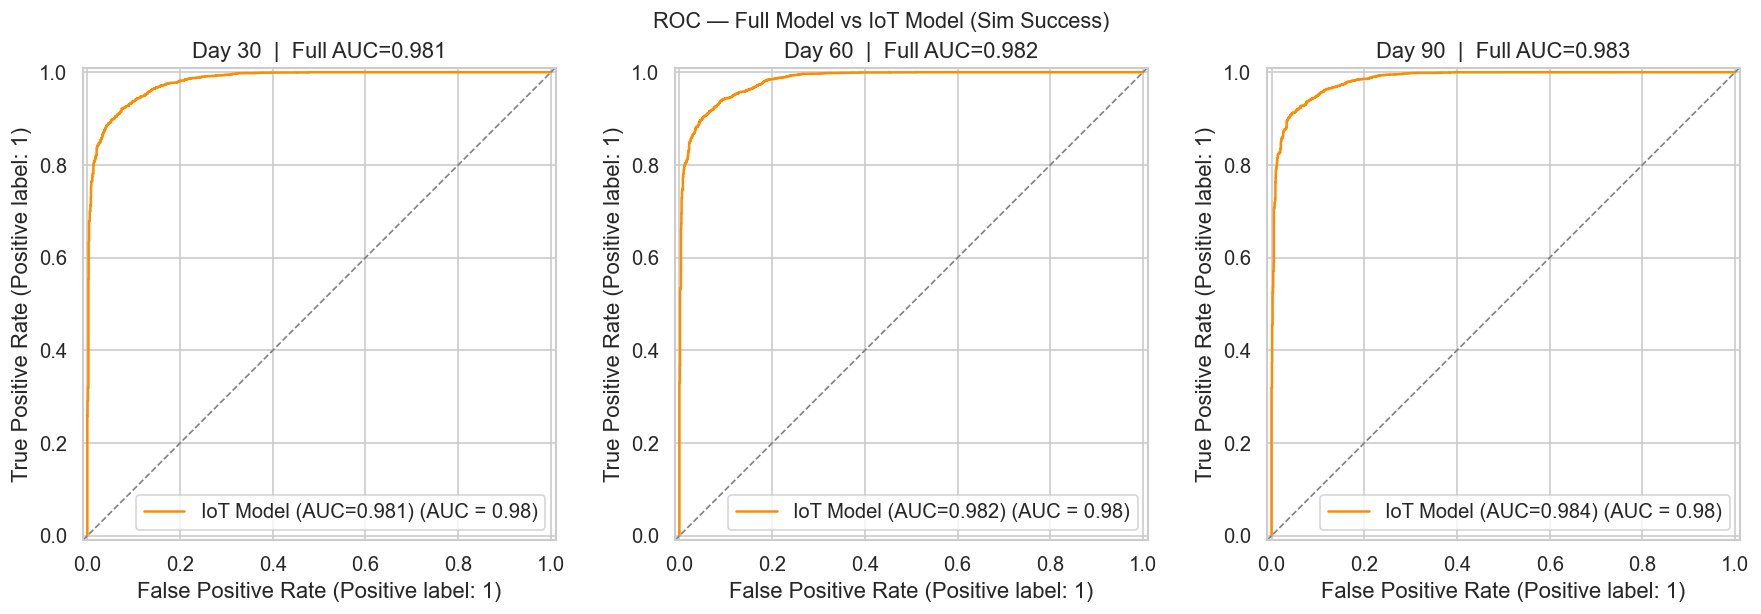

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, n in zip(axes, CUTOFFS):
    RocCurveDisplay.from_predictions(
        results[n]['y_te'], results[n]['y_proba'], ax=ax,
        name=f'IoT Model (AUC={results[n]["auc"]:.3f})',
        color='darkorange',
    )
    ax.axline((0,0),(1,1), ls='--', color='gray', lw=1)
    ax.set_title(f'Day {n}  |  Full AUC={FULL_AUC[n]:.3f}')
    ax.legend(loc='lower right')

plt.suptitle('ROC — Full Model vs IoT Model (Sim Success)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / 'iot_sim_success_roc.png', bbox_inches='tight')
plt.show()

## 6. SHAP — Alarm sistemi için hangi sensör önemli?

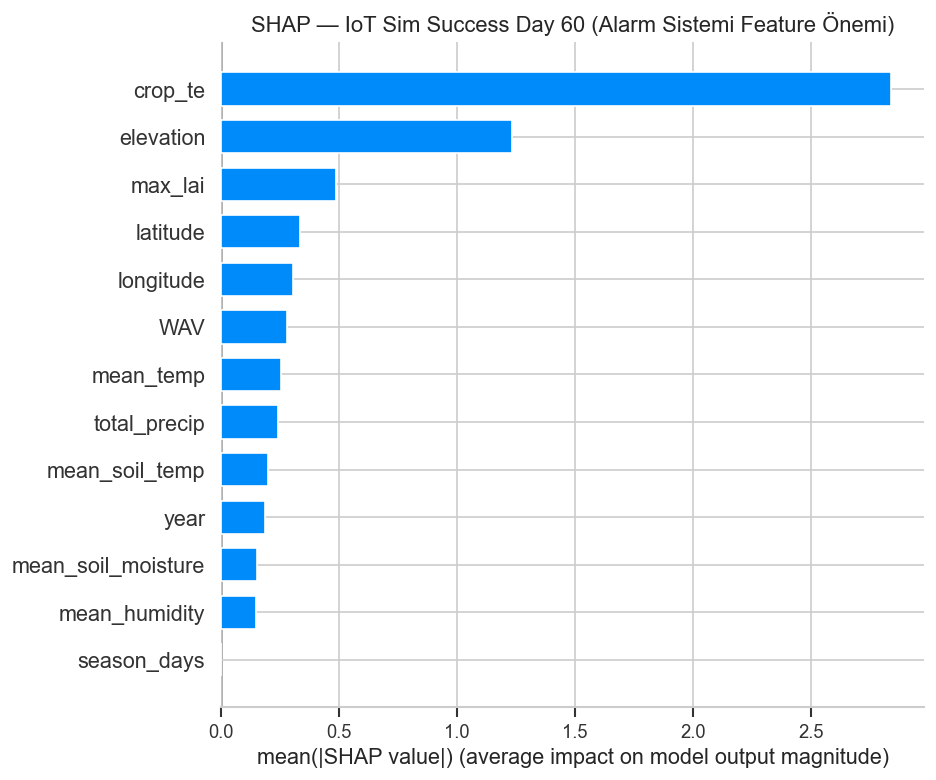

In [8]:
model_60 = results[60]['model']
X_te_60  = results[60]['X_te']

explainer   = shap.TreeExplainer(model_60)
shap_values = explainer.shap_values(X_te_60)

# LightGBM binary classification: shap_values[1] = pozitif sınıf
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_te_60, plot_type='bar', show=False)
plt.title('SHAP — IoT Sim Success Day 60 (Alarm Sistemi Feature Önemi)')
plt.tight_layout()
plt.savefig(FIGS / 'iot_sim_success_shap.png', bbox_inches='tight')
plt.show()

## 7. Alarm eşiği kalibrasyonu

Farklı başarısızlık olasılığı eşiklerinde precision / recall dengesi.

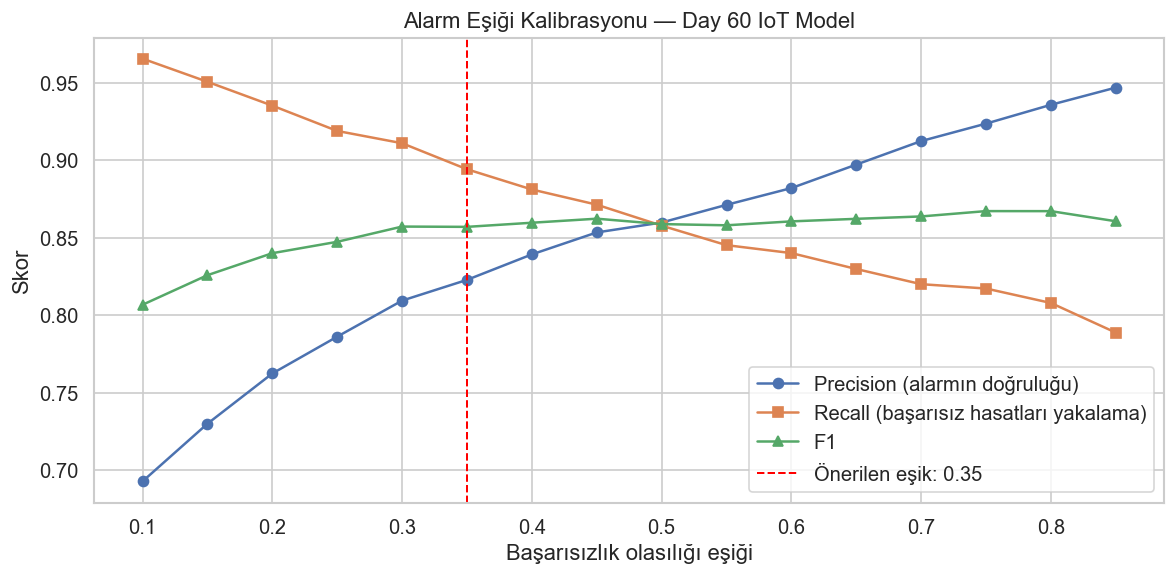


Önerilen eşik (0.35) performansı:
 threshold  alarm_rate  precision   recall       f1
      0.35    0.243956   0.822823 0.894172 0.857015


In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

n = 60
y_te    = results[n]['y_te'].values
y_proba = results[n]['y_proba']

# Başarısızlık olasılığı = 1 - başarı olasılığı
fail_proba = 1 - y_proba

thresholds = np.arange(0.1, 0.9, 0.05)
rows = []
for t in thresholds:
    y_hat = (fail_proba >= t).astype(int)
    # Başarısız hasatları yakalamak istiyoruz (y=0)
    y_fail = (1 - y_te)
    y_hat_fail = (fail_proba >= t).astype(int)
    if y_hat_fail.sum() == 0:
        continue
    rows.append({
        'threshold': round(t, 2),
        'alarm_rate': y_hat_fail.mean(),
        'precision': precision_score(y_fail, y_hat_fail, zero_division=0),
        'recall':    recall_score(y_fail, y_hat_fail, zero_division=0),
        'f1':        f1_score(y_fail, y_hat_fail, zero_division=0),
    })

calib = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(calib['threshold'], calib['precision'], marker='o', label='Precision (alarmın doğruluğu)')
ax.plot(calib['threshold'], calib['recall'],    marker='s', label='Recall (başarısız hasatları yakalama)')
ax.plot(calib['threshold'], calib['f1'],        marker='^', label='F1')
ax.axvline(0.35, ls='--', color='red', lw=1.2, label='Önerilen eşik: 0.35')
ax.set_xlabel('Başarısızlık olasılığı eşiği')
ax.set_ylabel('Skor')
ax.set_title('Alarm Eşiği Kalibrasyonu — Day 60 IoT Model')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / 'iot_sim_success_threshold.png', bbox_inches='tight')
plt.show()

print('\nÖnerilen eşik (0.35) performansı:')
print(calib[calib['threshold'] == 0.35].to_string(index=False))

## 8. Modelleri kaydet

In [10]:
summary = {}
print(f"{'Gün':<6} {'Full AUC':>10} {'IoT AUC':>10} {'ΔAUC':>8}")
print('-' * 38)

for n in CUTOFFS:
    auc_i = results[n]['auc']
    auc_f = FULL_AUC[n]
    print(f"{n:<6} {auc_f:>10.4f} {auc_i:>10.4f} {auc_f - auc_i:>+8.4f}")

    path = MODELS / f'iot_sim_success_lgbm_day{n}.joblib'
    joblib.dump(results[n]['model'], path)
    summary[str(n)] = {'full_auc': auc_f, 'iot_auc': round(auc_i, 4)}

with open(OUTPUTS / 'metrics' / 'iot_sim_success_metrics.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('\nTüm IoT sim_success modelleri kaydedildi.')

Gün      Full AUC    IoT AUC     ΔAUC
--------------------------------------
30         0.9810     0.9810  +0.0000
60         0.9819     0.9824  -0.0005
90         0.9828     0.9840  -0.0012

Tüm IoT sim_success modelleri kaydedildi.


## 9. Karar

In [11]:
print('=== KARAR ===')
for n in CUTOFFS:
    auc = results[n]['auc']
    if auc >= 0.95:
        status = '✅ Alarm sistemi production\'a hazır'
    elif auc >= 0.90:
        status = '⚠️  Kabul edilebilir — eşik kalibrasyonuyla kullanılabilir'
    else:
        status = '❌ Ek geliştirme gerekli'
    print(f'Day {n:3d} | AUC={auc:.4f} | {status}')

=== KARAR ===
Day  30 | AUC=0.9810 | ✅ Alarm sistemi production'a hazır
Day  60 | AUC=0.9824 | ✅ Alarm sistemi production'a hazır
Day  90 | AUC=0.9840 | ✅ Alarm sistemi production'a hazır
